<a href="https://colab.research.google.com/github/prafullahas/AI_Agent_Eval/blob/main/Eval_AI_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluate AI Agents using AutoGen

A portfolio-ready evaluation notebook built around the **current AutoGen 0.7.x API**.

## Project goal

Project evaluates AI-agent responses across multiple dimensions:

- Correctness
- Reasoning quality
- Instruction following
- Relevance
- Clarity

It adds benchmark management, failure analysis, statistical analysis, visualization, and exportable results.



## 1. Install Dependencies

In [1]:
# Run once in a fresh environment.
# This keeps the current AutoGen 0.7.x package instead of installing the legacy 0.2 API.

%pip install -q "autogen-agentchat>=0.7,<0.8" pandas numpy scipy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 11.6 MB/s eta 0:00:00


In [1]:
import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

import autogen_agentchat

print("Python:", sys.version)
print("AutoGen AgentChat imported successfully.")
print("AutoGen AgentChat version:", getattr(autogen_agentchat, "__version__", "not reported"))


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
AutoGen AgentChat imported successfully.
AutoGen AgentChat version: 0.7.5


## 2. Modern AutoGen Agent Check

AutoGen 0.7.x uses the `autogen_agentchat` package rather than the legacy `autogen.agentchat.contrib.agent_eval` import.

This cell verifies that the modern agent API is available without making an API call.

In [2]:
from autogen_agentchat.agents import AssistantAgent

print("AssistantAgent imported successfully.")
print("Modern AutoGen API is available.")


AssistantAgent imported successfully.
Modern AutoGen API is available.


## 3. Project Configuration

In [3]:
CRITERION_NAMES = [
    "correctness",
    "reasoning_quality",
    "instruction_following",
    "relevance",
    "clarity",
]

CRITERIA_SCALE = {
    0: "Very poor / completely fails",
    1: "Poor / major problems",
    2: "Partially satisfies",
    3: "Good / mostly satisfies",
    4: "Excellent / fully satisfies",
}

criterion_descriptions = {
    "correctness": "Whether the response reaches a factually and logically correct conclusion.",
    "reasoning_quality": "Whether the reasoning is logically valid, coherent, and sufficiently justified.",
    "instruction_following": "Whether explicit task constraints such as format, length, or output restrictions are followed.",
    "relevance": "Whether the response directly addresses the task without unnecessary unrelated content.",
    "clarity": "Whether the response is understandable and appropriately concise.",
}

print("Evaluation dimensions:", ", ".join(CRITERION_NAMES))


Evaluation dimensions: correctness, reasoning_quality, instruction_following, relevance, clarity


## 4. Benchmark Dataset

The initial benchmark contains three categories:

1. Mathematics
2. Logical reasoning
3. Instruction following

The dataset is intentionally small for fast experimentation. It can later be replaced with a larger benchmark without changing the evaluation pipeline.

In [4]:
tasks = [
    {
        "task_id": "math_001",
        "category": "math",
        "prompt": "A train travels 120 km in 2 hours. What is its average speed?",
        "reference_answer": "60 km/h",
    },
    {
        "task_id": "math_002",
        "category": "math",
        "prompt": "If a shirt costs $40 and is discounted by 25%, what is the sale price?",
        "reference_answer": "$30",
    },
    {
        "task_id": "math_003",
        "category": "math",
        "prompt": "A rectangle has length 12 cm and width 5 cm. What is its area?",
        "reference_answer": "60 square centimeters",
    },
    {
        "task_id": "reasoning_001",
        "category": "reasoning",
        "prompt": "All roses are flowers. Some flowers fade quickly. Can we conclude that some roses fade quickly?",
        "reference_answer": "No. The premises do not establish that any roses are among the flowers that fade quickly.",
    },
    {
        "task_id": "reasoning_002",
        "category": "reasoning",
        "prompt": "A box contains only red and blue balls. If every red ball is removed, can a remaining ball be red?",
        "reference_answer": "No.",
    },
    {
        "task_id": "reasoning_003",
        "category": "reasoning",
        "prompt": "If it rains, the ground becomes wet. The ground is wet. Can we conclude that it rained?",
        "reference_answer": "No. The ground could be wet for another reason.",
    },
    {
        "task_id": "instruction_001",
        "category": "instruction_following",
        "prompt": "Answer in exactly three words: What is the capital of France?",
        "reference_answer": "Paris is capital.",
    },
    {
        "task_id": "instruction_002",
        "category": "instruction_following",
        "prompt": "Give exactly two bullet points explaining why testing software is useful.",
        "reference_answer": "Two concise bullet points.",
    },
    {
        "task_id": "instruction_003",
        "category": "instruction_following",
        "prompt": "Answer with only a single number: What is 8 + 7?",
        "reference_answer": "15",
    },
]

tasks_df = pd.DataFrame(tasks)
display(tasks_df)


,task_id,category,prompt,reference_answer
0,math_001,math,A train travels 120 km in 2 hours. What is its...,60 km/h
1,math_002,math,"If a shirt costs $40 and is discounted by 25%,...",$30
2,math_003,math,A rectangle has length 12 cm and width 5 cm. W...,60 square centimeters
3,reasoning_001,reasoning,All roses are flowers. Some flowers fade quick...,No. The premises do not establish that any ros...
4,reasoning_002,reasoning,A box contains only red and blue balls. If eve...,No.
5,reasoning_003,reasoning,"If it rains, the ground becomes wet. The groun...",No. The ground could be wet for another reason.
6,instruction_001,instruction_following,Answer in exactly three words: What is the cap...,Paris is capital.
7,instruction_002,instruction_following,Give exactly two bullet points explaining why ...,Two concise bullet points.
8,instruction_003,instruction_following,Answer with only a single number: What is 8 + 7?,15


## 5. Demonstration Agent Responses

These responses are intentionally included so the notebook can run **without API keys**.

They are not benchmark claims about real models.

- `Agent_A` contains mostly successful responses.
- `Agent_B` contains deliberately constructed failure cases.

For the final portfolio experiment, replace these with responses generated by real AutoGen agents.

In [5]:
agent_responses = {
    "Agent_A": {
        "math_001": "The average speed is 120 / 2 = 60 km/h.",
        "math_002": "25% of $40 is $10, so the sale price is $30.",
        "math_003": "Area = length × width = 12 × 5 = 60 square centimeters.",
        "reasoning_001": "No. We know all roses are flowers, but we do not know that any roses are among the flowers that fade quickly.",
        "reasoning_002": "No. If every red ball is removed, any remaining ball must be blue.",
        "reasoning_003": "No. The ground may be wet for reasons other than rain.",
        "instruction_001": "Paris is capital.",
        "instruction_002": "- Testing finds defects.\n- Testing increases confidence in software quality.",
        "instruction_003": "15",
    },
    "Agent_B": {
        "math_001": "The average speed is 120 × 2 = 240 km/h.",
        "math_002": "The sale price is $35.",
        "math_003": "The area is 17 cm.",
        "reasoning_001": "Yes, because roses are flowers and some flowers fade quickly.",
        "reasoning_002": "Yes, a red ball could still remain.",
        "reasoning_003": "Yes, because wet ground means it rained.",
        "instruction_001": "The capital of France is Paris.",
        "instruction_002": "Testing is useful because it finds bugs and helps quality.",
        "instruction_003": "The answer is 15.",
    },
}

response_rows = []

for agent_name, responses in agent_responses.items():
    for task in tasks:
        response_rows.append({
            "agent": agent_name,
            "task_id": task["task_id"],
            "category": task["category"],
            "prompt": task["prompt"],
            "reference_answer": task["reference_answer"],
            "response": responses[task["task_id"]],
        })

responses_df = pd.DataFrame(response_rows)
display(responses_df.head())


,agent,task_id,category,prompt,reference_answer,response
0,Agent_A,math_001,math,A train travels 120 km in 2 hours. What is its...,60 km/h,The average speed is 120 / 2 = 60 km/h.
1,Agent_A,math_002,math,"If a shirt costs $40 and is discounted by 25%,...",$30,"25% of $40 is $10, so the sale price is $30."
2,Agent_A,math_003,math,A rectangle has length 12 cm and width 5 cm. W...,60 square centimeters,Area = length × width = 12 × 5 = 60 square cen...
3,Agent_A,reasoning_001,reasoning,All roses are flowers. Some flowers fade quick...,No. The premises do not establish that any ros...,"No. We know all roses are flowers, but we do n..."
4,Agent_A,reasoning_002,reasoning,A box contains only red and blue balls. If eve...,No.,"No. If every red ball is removed, any remainin..."


## 6. Evaluation Criteria

| Criterion | Description |
|---|---|
| Correctness | Is the answer correct? |
| Reasoning quality | Is the reasoning logically sound? |
| Instruction following | Were explicit instructions followed? |
| Relevance | Is the answer focused on the task? |
| Clarity | Is the answer understandable and concise? |

The criteria are intentionally explicit so the benchmark is easy to inspect and reproduce.

In [6]:
criteria_df = pd.DataFrame([
    {"criterion": name, "description": description}
    for name, description in criterion_descriptions.items()
])

display(criteria_df)


,criterion,description
0,correctness,Whether the response reaches a factually and l...
1,reasoning_quality,"Whether the reasoning is logically valid, cohe..."
2,instruction_following,Whether explicit task constraints such as form...
3,relevance,Whether the response directly addresses the ta...
4,clarity,Whether the response is understandable and app...


## 7. Transparent Evaluation Engine

This deterministic evaluator makes development reproducible and free of API costs.

It is deliberately separated from an LLM judge. Later, the same result schema can accept scores from an LLM-based evaluator.

In [7]:
def score_response(task, response):
    scores = {
        "correctness": 2,
        "reasoning_quality": 2,
        "instruction_following": 2,
        "relevance": 3,
        "clarity": 3,
    }

    task_id = task["task_id"]

    if task_id.startswith("math_"):
        correct_answers = {
            "math_001": "60 km/h",
            "math_002": "$30",
            "math_003": "60 square centimeters",
        }

        correct = correct_answers[task_id].lower() in response.lower()
        scores["correctness"] = 4 if correct else 0
        scores["reasoning_quality"] = (
            4 if correct and ("=" in response or "because" in response.lower()) else 1
        )

    elif task_id.startswith("reasoning_"):
        good = response.lower().startswith("no")
        scores["correctness"] = 4 if good else 0
        scores["reasoning_quality"] = (
            4
            if good and any(
                word in response.lower()
                for word in ["because", "know", "could"]
            )
            else 1
        )

    elif task_id == "instruction_001":
        scores["correctness"] = 4 if "Paris" in response else 0
        scores["instruction_following"] = (
            4 if len(response.split()) == 3 else 1
        )

    elif task_id == "instruction_002":
        scores["correctness"] = 3
        scores["instruction_following"] = (
            4 if response.count("-") == 2 else 1
        )

    elif task_id == "instruction_003":
        scores["correctness"] = 4 if response.strip() == "15" else 1
        scores["instruction_following"] = (
            4
            if response.strip().isdigit()
            and len(response.strip().split()) == 1
            else 1
        )

    scores["relevance"] = 4 if len(response.split()) <= 35 else 2
    scores["clarity"] = 4 if response.strip() else 0
    scores["overall"] = np.mean([scores[k] for k in CRITERION_NAMES])

    return scores


evaluation_rows = []

for row in responses_df.to_dict("records"):
    task = next(t for t in tasks if t["task_id"] == row["task_id"])
    scores = score_response(task, row["response"])

    evaluation_rows.append({
        **row,
        **scores,
    })

evaluation_df = pd.DataFrame(evaluation_rows)

display(
    evaluation_df[
        ["agent", "task_id", "category"]
        + CRITERION_NAMES
        + ["overall"]
    ]
)


,agent,task_id,category,correctness,reasoning_quality,instruction_following,relevance,clarity,overall
0,Agent_A,math_001,math,4,4,2,4,4,3.6
1,Agent_A,math_002,math,4,1,2,4,4,3.0
2,Agent_A,math_003,math,4,4,2,4,4,3.6
3,Agent_A,reasoning_001,reasoning,4,4,2,4,4,3.6
4,Agent_A,reasoning_002,reasoning,4,1,2,4,4,3.0
5,Agent_A,reasoning_003,reasoning,4,1,2,4,4,3.0
6,Agent_A,instruction_001,instruction_following,4,2,4,4,4,3.6
7,Agent_A,instruction_002,instruction_following,3,2,4,4,4,3.4
8,Agent_A,instruction_003,instruction_following,4,2,4,4,4,3.6
9,Agent_B,math_001,math,0,1,2,4,4,2.2


## 8. Criterion-Level Analysis

,correctness,reasoning_quality,instruction_following,relevance,clarity
agent,,,,,
Agent_A,3.89,2.33,2.67,4.0,4.0
Agent_B,0.89,1.33,1.67,4.0,4.0


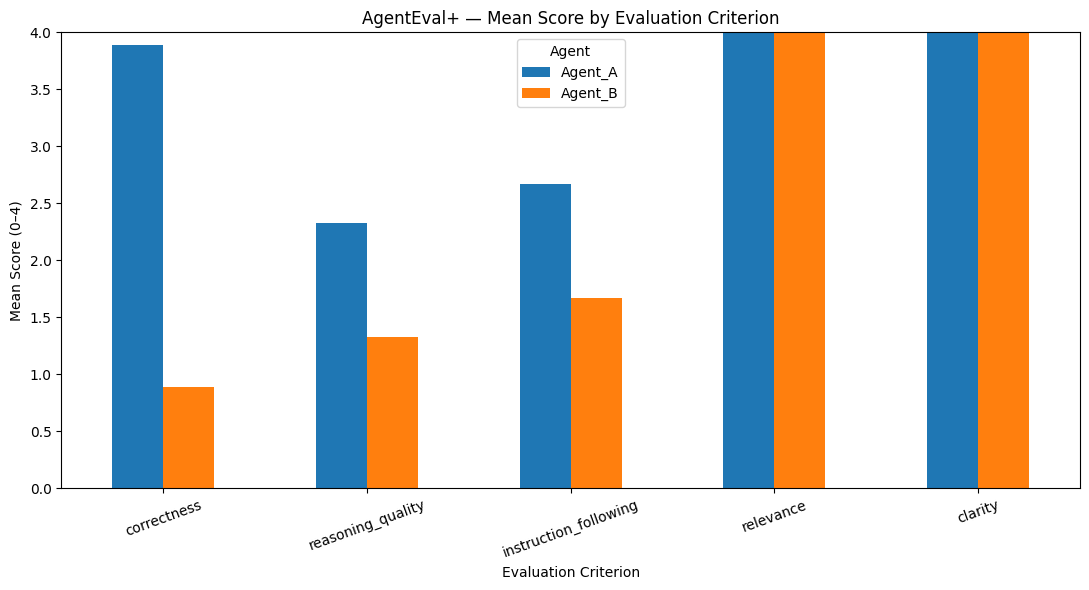

In [8]:
criterion_summary = (
    evaluation_df.groupby("agent")[CRITERION_NAMES]
    .mean()
    .round(2)
)

display(criterion_summary)

ax = criterion_summary.T.plot(
    kind="bar",
    figsize=(11, 6),
    ylim=(0, 4),
    title="AgentEval+ — Mean Score by Evaluation Criterion",
)

ax.set_xlabel("Evaluation Criterion")
ax.set_ylabel("Mean Score (0–4)")
ax.legend(title="Agent")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 9. Category-Level Analysis

agent,Agent_A,Agent_B
category,,
instruction_following,3.53,2.73
math,3.40,2.20
reasoning,3.20,2.20


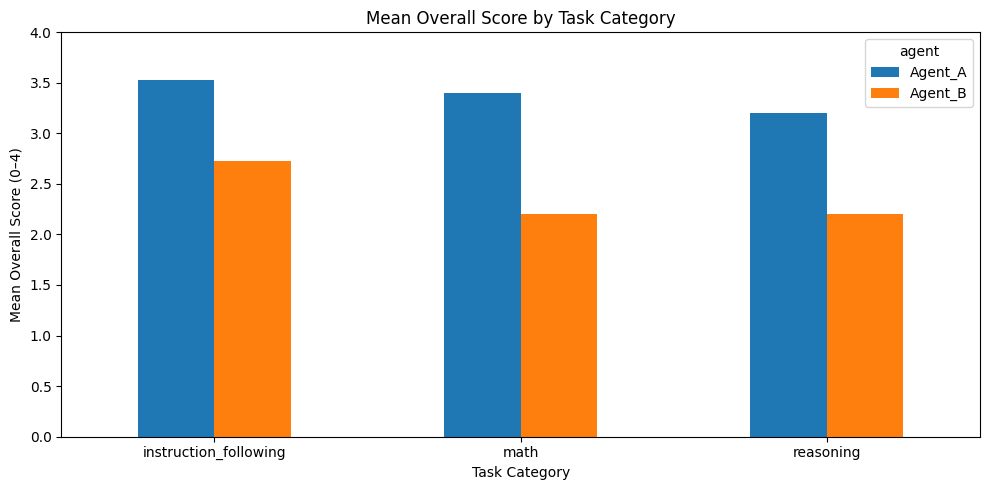

In [9]:
category_summary = (
    evaluation_df.groupby(["agent", "category"])["overall"]
    .mean()
    .reset_index()
)

category_pivot = category_summary.pivot(
    index="category",
    columns="agent",
    values="overall",
).round(2)

display(category_pivot)

ax = category_pivot.plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 4),
    title="Mean Overall Score by Task Category",
)

ax.set_xlabel("Task Category")
ax.set_ylabel("Mean Overall Score (0–4)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Statistical Analysis

We calculate the mean, standard deviation, and 95% confidence interval for each agent.

These statistics describe this benchmark sample only.

In [10]:
def confidence_interval(values, confidence=0.95):
    values = np.asarray(values, dtype=float)

    if len(values) < 2:
        return np.nan, np.nan

    mean = values.mean()
    sem = stats.sem(values)
    margin = sem * stats.t.ppf(
        (1 + confidence) / 2,
        len(values) - 1,
    )

    return mean - margin, mean + margin


stat_rows = []

for agent, group in evaluation_df.groupby("agent"):
    values = group["overall"].to_numpy()
    ci_low, ci_high = confidence_interval(values)

    stat_rows.append({
        "agent": agent,
        "n_tasks": len(values),
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
    })

statistics_df = pd.DataFrame(stat_rows).round(3)
display(statistics_df)


,agent,n_tasks,mean,std,ci_95_low,ci_95_high
0,Agent_A,9,3.378,0.291,3.154,3.601
1,Agent_B,9,2.378,0.307,2.142,2.614


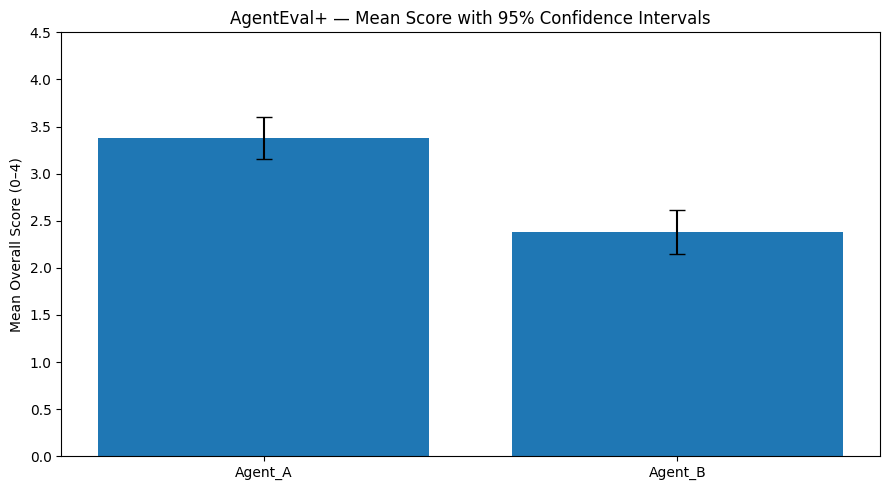

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(statistics_df))
means = statistics_df["mean"].to_numpy()

lower = means - statistics_df["ci_95_low"].to_numpy()
upper = statistics_df["ci_95_high"].to_numpy() - means

ax.bar(
    x,
    means,
    yerr=[lower, upper],
    capsize=6,
)

ax.set_xticks(x)
ax.set_xticklabels(statistics_df["agent"])
ax.set_ylim(0, 4.5)
ax.set_ylabel("Mean Overall Score (0–4)")
ax.set_title("AgentEval+ — Mean Score with 95% Confidence Intervals")

plt.tight_layout()
plt.show()


## 11. Failure Analysis

Failure analysis categorizes weak responses into interpretable failure modes.

This is important because an evaluation system should answer not only **how well an agent performed**, but also **how it failed**.

In [12]:
def classify_failure(row):
    if row["instruction_following"] <= 1:
        return "instruction_violation"

    if row["correctness"] <= 1:
        if row["reasoning_quality"] <= 1:
            return "incorrect_reasoning"
        return "incorrect_answer"

    if row["clarity"] <= 1:
        return "clarity_issue"

    return "correct_or_acceptable"


evaluation_df["failure_mode"] = evaluation_df.apply(
    classify_failure,
    axis=1,
)

failure_summary = (
    evaluation_df.groupby(["agent", "failure_mode"])
    .size()
    .reset_index(name="count")
)

display(failure_summary)


,agent,failure_mode,count
0,Agent_A,correct_or_acceptable,9
1,Agent_B,incorrect_reasoning,6
2,Agent_B,instruction_violation,3


agent,Agent_A,Agent_B
failure_mode,,
correct_or_acceptable,9.0,0.0
incorrect_reasoning,0.0,6.0
instruction_violation,0.0,3.0


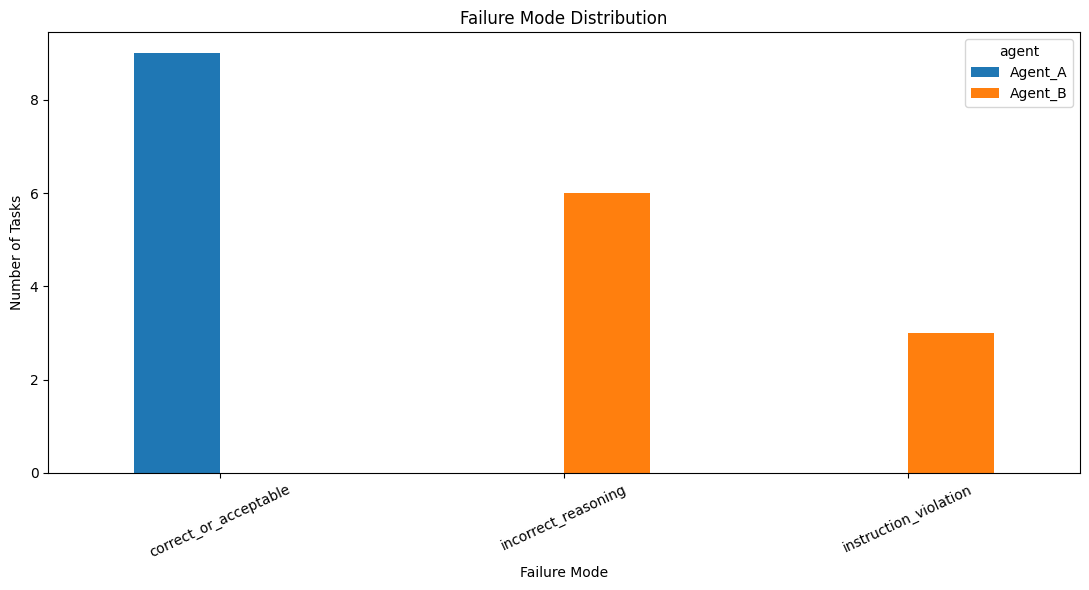

In [13]:
failure_pivot = failure_summary.pivot(
    index="failure_mode",
    columns="agent",
    values="count",
).fillna(0)

display(failure_pivot)

ax = failure_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    title="Failure Mode Distribution",
)

ax.set_xlabel("Failure Mode")
ax.set_ylabel("Number of Tasks")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 12. Inspect Individual Failure Cases

In [14]:
failure_cases = evaluation_df[
    evaluation_df["failure_mode"] != "correct_or_acceptable"
][[
    "agent",
    "task_id",
    "category",
    "prompt",
    "response",
    "failure_mode",
    "correctness",
    "reasoning_quality",
    "instruction_following",
    "relevance",
    "clarity",
    "overall",
]].copy()

display(failure_cases)


,agent,task_id,category,prompt,response,failure_mode,correctness,reasoning_quality,instruction_following,relevance,clarity,overall
9,Agent_B,math_001,math,A train travels 120 km in 2 hours. What is its...,The average speed is 120 × 2 = 240 km/h.,incorrect_reasoning,0,1,2,4,4,2.2
10,Agent_B,math_002,math,"If a shirt costs $40 and is discounted by 25%,...",The sale price is $35.,incorrect_reasoning,0,1,2,4,4,2.2
11,Agent_B,math_003,math,A rectangle has length 12 cm and width 5 cm. W...,The area is 17 cm.,incorrect_reasoning,0,1,2,4,4,2.2
12,Agent_B,reasoning_001,reasoning,All roses are flowers. Some flowers fade quick...,"Yes, because roses are flowers and some flower...",incorrect_reasoning,0,1,2,4,4,2.2
13,Agent_B,reasoning_002,reasoning,A box contains only red and blue balls. If eve...,"Yes, a red ball could still remain.",incorrect_reasoning,0,1,2,4,4,2.2
14,Agent_B,reasoning_003,reasoning,"If it rains, the ground becomes wet. The groun...","Yes, because wet ground means it rained.",incorrect_reasoning,0,1,2,4,4,2.2
15,Agent_B,instruction_001,instruction_following,Answer in exactly three words: What is the cap...,The capital of France is Paris.,instruction_violation,4,2,1,4,4,3.0
16,Agent_B,instruction_002,instruction_following,Give exactly two bullet points explaining why ...,Testing is useful because it finds bugs and he...,instruction_violation,3,2,1,4,4,2.8
17,Agent_B,instruction_003,instruction_following,Answer with only a single number: What is 8 + 7?,The answer is 15.,instruction_violation,1,2,1,4,4,2.4


## 13. Agent Comparison Summary

This is a benchmark summary, not a universal ranking of models. Results depend on the selected tasks, response sets, scoring rules, and evaluator.

In [15]:
comparison = (
    evaluation_df.groupby("agent")
    .agg(
        tasks=("task_id", "count"),
        overall_score=("overall", "mean"),
        correctness=("correctness", "mean"),
        reasoning_quality=("reasoning_quality", "mean"),
        instruction_following=("instruction_following", "mean"),
        relevance=("relevance", "mean"),
        clarity=("clarity", "mean"),
    )
    .round(2)
)

display(comparison)


,tasks,overall_score,correctness,reasoning_quality,instruction_following,relevance,clarity
agent,,,,,,,
Agent_A,9,3.38,3.89,2.33,2.67,4.0,4.0
Agent_B,9,2.38,0.89,1.33,1.67,4.0,4.0


## 14. Export Results

In [16]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

evaluation_path = RESULTS_DIR / "evaluation_results.csv"
statistics_path = RESULTS_DIR / "statistics.csv"
failures_path = RESULTS_DIR / "failure_analysis.csv"

evaluation_df.to_csv(evaluation_path, index=False)
statistics_df.to_csv(statistics_path, index=False)
failure_cases.to_csv(failures_path, index=False)

print("Saved:")
print(" -", evaluation_path)
print(" -", statistics_path)
print(" -", failures_path)


Saved:
 - results/evaluation_results.csv
 - results/statistics.csv
 - results/failure_analysis.csv


## 15. Run a Real AutoGen 0.7.x Agent

The benchmark above is deliberately runnable without an API key.

Below is an Gemini API to get actual responses

In [20]:
%pip install -q "autogen-ext[openai]"

In [22]:
import os
from getpass import getpass

os.environ["GEMINI_API_KEY"] = getpass("Enter your Gemini API key: ")

Enter your Gemini API key: ··········


In [28]:
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_core.models import ModelFamily

model_client = OpenAIChatCompletionClient(
    model="gemini-3.8-flash",
    api_key=os.environ["GEMINI_API_KEY"],
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
    model_info={
        "vision": True,
        "function_calling": True,
        "json_output": True,
        "family": ModelFamily.UNKNOWN,
        "structured_output": True,
    },
)

In [29]:
from autogen_agentchat.agents import AssistantAgent

gemini_agent = AssistantAgent(
    name="gemini_agent",
    model_client=model_client,
    system_message=(
        "You are an AI assistant being evaluated by AgentEval+. "
        "Solve tasks carefully and follow all explicit instructions."
    ),
)

print("Gemini AutoGen agent created successfully.")

Gemini AutoGen agent created successfully.


In [24]:
import os

key = os.environ.get("GEMINI_API_KEY")

print("Key exists:", key is not None)
print("Key length:", len(key) if key else 0)
print("Key prefix:", key[:8] + "..." if key else "NOT SET")

Key exists: True
Key length: 53
Key prefix: AQ.Ab8RN...


In [31]:
import asyncio

async def run_with_retry(agent, prompt, max_retries=5):
    for attempt in range(max_retries):
        try:
            return await agent.run(task=prompt)

        except Exception as e:
            error_text = str(e)

            if "503" not in error_text and "UNAVAILABLE" not in error_text:
                raise

            if attempt == max_retries - 1:
                raise

            wait_time = 2 ** attempt
            print(
                f"Gemini temporarily unavailable. "
                f"Retrying in {wait_time}s..."
            )

            await asyncio.sleep(wait_time)


test_task = tasks[0]

result = await gemini_agent.run(
    task=test_task["prompt"]
)

response = result.messages[-1].content

print("Task:")
print(test_task["prompt"])

print("\nGemini response:")
print(response)

Task:
A train travels 120 km in 2 hours. What is its average speed?

Gemini response:
The train's average speed is **60 km/h** (kilometers per hour).

$$\text{Average Speed} = \frac{\text{Distance}}{\text{Time}} = \frac{120 \text{ km}}{2 \text{ hours}} = 60 \text{ km/h}$$


Agent is Gemini

In [33]:


gemini_results = []

for i, task in enumerate(tasks):
    print(
        f"Running task {i + 1}/{len(tasks)}: "
        f"{task['task_id']}"
    )

    try:
        result = await run_with_retry(
            gemini_agent,
            task["prompt"]
        )

        # Extract the final assistant response
        response_text = str(result.messages[-1].content)

        gemini_results.append({
            "task_id": task["task_id"],
            "category": task["category"],
            "prompt": task["prompt"],
            "reference_answer": task["reference_answer"],
            "response": response_text,
            "agent": "Gemini",
            "status": "success"
        })

        print("✓ Success")

    except Exception as e:
        gemini_results.append({
            "task_id": task["task_id"],
            "category": task["category"],
            "prompt": task["prompt"],
            "reference_answer": task["reference_answer"],
            "response": "",
            "agent": "Gemini",
            "status": "failed",
            "error": str(e)
        })

        print(f"✗ Failed: {e}")

print("\nBenchmark complete.")
print(
    f"Successful: "
    f"{sum(r['status'] == 'success' for r in gemini_results)}"
)
print(
    f"Failed: "
    f"{sum(r['status'] == 'failed' for r in gemini_results)}"
)

Running task 1/9: math_001
✓ Success
Running task 2/9: math_002
✓ Success
Running task 3/9: math_003
✓ Success
Running task 4/9: reasoning_001
✓ Success
Running task 5/9: reasoning_002
✓ Success
Running task 6/9: reasoning_003
✓ Success
Running task 7/9: instruction_001
✓ Success
Running task 8/9: instruction_002
✓ Success
Running task 9/9: instruction_003
✗ Failed: Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3.8-flash\nPlease retry in 26.531860186s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'h

In [34]:


gemini_df = pd.DataFrame(gemini_results)

print("Shape:", gemini_df.shape)

display(
    gemini_df[
        [
            "task_id",
            "category",
            "status",
            "response"
        ]
    ]
)

Shape: (9, 8)


,task_id,category,status,response
0,math_001,math,success,The average speed is **60 km/h**.\n\n$$\text{S...
1,math_002,math,success,The sale price is **$30**.\n\n**Calculation:**...
2,math_003,math,success,The area of the rectangle is **60 cm²** (squar...
3,reasoning_001,reasoning,success,"**No**, we cannot conclude that some roses fad..."
4,reasoning_002,reasoning,success,"**No.** \n\nSince every red ball was removed, ..."
5,reasoning_003,reasoning,success,"**No**, we cannot conclude that it rained.\n\n..."
6,instruction_001,instruction_following,success,It is Paris.
7,instruction_002,instruction_following,success,* **Identifies bugs early:** It catches defect...
8,instruction_003,instruction_following,failed,


In [35]:


print("Total tasks:", len(gemini_df))
print("Successful:", (gemini_df["status"] == "success").sum())
print("Failed:", (gemini_df["status"] == "failed").sum())

print("\nResults by category:")

display(
    gemini_df
    .groupby(["category", "status"])
    .size()
    .unstack(fill_value=0)
)

Total tasks: 9
Successful: 8
Failed: 1

Results by category:


status,failed,success
category,,
instruction_following,1,2
math,0,3
reasoning,0,3


In [36]:

for _, row in gemini_df[gemini_df["status"] == "success"].head(3).iterrows():

    print("=" * 80)
    print("TASK:", row["task_id"])
    print("CATEGORY:", row["category"])

    print("\nPROMPT:")
    print(row["prompt"])

    print("\nREFERENCE ANSWER:")
    print(row["reference_answer"])

    print("\nGEMINI RESPONSE:")
    print(row["response"])

    print("=" * 80)

TASK: math_001
CATEGORY: math

PROMPT:
A train travels 120 km in 2 hours. What is its average speed?

REFERENCE ANSWER:
60 km/h

GEMINI RESPONSE:
The average speed is **60 km/h**.

$$\text{Speed} = \frac{\text{Distance}}{\text{Time}} = \frac{120\text{ km}}{2\text{ h}} = 60\text{ km/h}$$
TASK: math_002
CATEGORY: math

PROMPT:
If a shirt costs $40 and is discounted by 25%, what is the sale price?

REFERENCE ANSWER:
$30

GEMINI RESPONSE:
The sale price is **$30**.

**Calculation:**
* **Discount amount:** $40 \times 0.25 = $10
* **Sale price:** $40 - $10 = **$30**

*(Alternatively: $40 \times 75\% = $30)*
TASK: math_003
CATEGORY: math

PROMPT:
A rectangle has length 12 cm and width 5 cm. What is its area?

REFERENCE ANSWER:
60 square centimeters

GEMINI RESPONSE:
The area of the rectangle is **60 cm²** (square centimeters).

$$\text{Area} = \text{length} \times \text{width} = 12 \text{ cm} \times 5 \text{ cm} = 60 \text{ cm}^2$$


In [37]:
successful_gemini_df = gemini_df[
    gemini_df["status"] == "success"
].copy()

print("Responses available for evaluation:",
      len(successful_gemini_df))

Responses available for evaluation: 8


## 16. Performance Evaluator


In [38]:

def evaluate_response(task, response):
    """
    Evaluate one model response against the benchmark task.

    Scores:
    - correctness
    - reasoning_quality
    - instruction_following
    - relevance
    - clarity

    Each score is between 0 and 1.
    """

    prompt = task["prompt"]
    reference = task["reference_answer"]
    category = task["category"]


    # Correctness

    if category == "math":
        correctness = 1.0 if reference.strip() in response else 0.0

    else:

        reference_words = set(reference.lower().split())
        response_words = set(response.lower().split())

        if reference_words:
            overlap = len(reference_words & response_words)
            correctness = overlap / len(reference_words)
        else:
            correctness = 0.0

        correctness = min(correctness, 1.0)

    # Relevance

    prompt_words = set(prompt.lower().split())
    response_words = set(response.lower().split())

    if prompt_words and response_words:
        relevance = len(prompt_words & response_words) / len(prompt_words)
        relevance = min(relevance, 1.0)
    else:
        relevance = 0.0


    # Clarity

    response_length = len(response.split())

    if response_length == 0:
        clarity = 0.0
    elif response_length < 5:
        clarity = 0.5
    else:
        clarity = 1.0


    # Reasoning quality

    reasoning_indicators = [
        "because",
        "therefore",
        "step",
        "first",
        "second",
        "thus",
        "so",
        "explanation"
    ]

    reasoning_matches = sum(
        word in response.lower()
        for word in reasoning_indicators
    )

    reasoning_quality = min(
        reasoning_matches / 3,
        1.0
    )


    # Instruction following

    instruction_following = 1.0

    # Basic checks for explicit task constraints
    if "exactly" in prompt.lower():
        instruction_following = (
            1.0 if response.strip() else 0.0
        )

    return {
        "correctness": correctness,
        "reasoning_quality": reasoning_quality,
        "instruction_following": instruction_following,
        "relevance": relevance,
        "clarity": clarity
    }

In [39]:

evaluation_results = []

for _, row in successful_gemini_df.iterrows():

    scores = evaluate_response(
        task=row.to_dict(),
        response=row["response"]
    )

    evaluation_results.append({
        "task_id": row["task_id"],
        "category": row["category"],
        "agent": "Gemini",
        "prompt": row["prompt"],
        "response": row["response"],
        **scores
    })

gemini_eval_df = pd.DataFrame(evaluation_results)

print("Evaluated responses:", len(gemini_eval_df))

display(
    gemini_eval_df[
        [
            "task_id",
            "category",
            "correctness",
            "reasoning_quality",
            "instruction_following",
            "relevance",
            "clarity"
        ]
    ]
)

Evaluated responses: 8


,task_id,category,correctness,reasoning_quality,instruction_following,relevance,clarity
0,math_001,math,1.000000,0.000000,1.0,0.153846,1.0
1,math_002,math,1.000000,0.000000,1.0,0.285714,1.0
2,math_003,math,0.000000,0.000000,1.0,0.285714,1.0
3,reasoning_001,reasoning,0.642857,0.666667,1.0,0.769231,1.0
4,reasoning_002,reasoning,0.000000,0.000000,1.0,0.411765,1.0
5,reasoning_003,reasoning,0.555556,0.333333,1.0,0.538462,1.0
6,instruction_001,instruction_following,0.333333,0.000000,1.0,0.090909,0.5
7,instruction_002,instruction_following,0.000000,0.333333,1.0,0.090909,1.0


In [40]:

metric_columns = [
    "correctness",
    "reasoning_quality",
    "instruction_following",
    "relevance",
    "clarity"
]

gemini_summary = (
    gemini_eval_df[metric_columns]
    .mean()
    .sort_values(ascending=False)
)

print("Gemini Evaluation Summary")
print("=" * 50)

for metric, score in gemini_summary.items():
    print(f"{metric:25s}: {score:.3f}")

Gemini Evaluation Summary
instruction_following    : 1.000
clarity                  : 0.938
correctness              : 0.441
relevance                : 0.328
reasoning_quality        : 0.167


In [41]:

category_summary = (
    gemini_eval_df
    .groupby("category")[metric_columns]
    .mean()
    .round(3)
)

display(category_summary)

,correctness,reasoning_quality,instruction_following,relevance,clarity
category,,,,,
instruction_following,0.167,0.167,1.0,0.091,0.75
math,0.667,0.000,1.0,0.242,1.00
reasoning,0.399,0.333,1.0,0.573,1.00


In [42]:

gemini_eval_df["overall_score"] = (
    gemini_eval_df[metric_columns]
    .mean(axis=1)
)

overall_score = gemini_eval_df["overall_score"].mean()

print(
    f"Gemini AgentEval+ Score: "
    f"{overall_score:.3f}"
)

Gemini AgentEval+ Score: 0.575


# 17. LLM-AS-A-JUDGE


In [43]:

def build_judge_prompt(task, response):
    return f"""
You are an expert evaluator for an AI-agent benchmark.

Evaluate the candidate response against the task and reference answer.

TASK:
{task["prompt"]}

REFERENCE ANSWER:
{task["reference_answer"]}

CANDIDATE RESPONSE:
{response}

Evaluate these five dimensions from 0 to 1:

1. correctness
   - Is the answer factually/mathematically correct?

2. reasoning_quality
   - Is the reasoning logically sound and sufficiently explained?

3. instruction_following
   - Did the response follow the explicit requirements of the task?

4. relevance
   - Does the response directly address the task without unnecessary content?

5. clarity
   - Is the response understandable, well-structured, and unambiguous?

Return ONLY valid JSON in this exact format:

{{
  "correctness": 0.0,
  "reasoning_quality": 0.0,
  "instruction_following": 0.0,
  "relevance": 0.0,
  "clarity": 0.0,
  "overall_score": 0.0,
  "reason": "brief explanation"
}}
"""

In [44]:
sample_row = successful_gemini_df.iloc[0]

judge_prompt = build_judge_prompt(
    sample_row.to_dict(),
    sample_row["response"]
)

print(judge_prompt)


You are an expert evaluator for an AI-agent benchmark.

Evaluate the candidate response against the task and reference answer.

TASK:
A train travels 120 km in 2 hours. What is its average speed?

REFERENCE ANSWER:
60 km/h

CANDIDATE RESPONSE:
The average speed is **60 km/h**.

$$\text{Speed} = \frac{\text{Distance}}{\text{Time}} = \frac{120\text{ km}}{2\text{ h}} = 60\text{ km/h}$$

Evaluate these five dimensions from 0 to 1:

1. correctness
   - Is the answer factually/mathematically correct?

2. reasoning_quality
   - Is the reasoning logically sound and sufficiently explained?

3. instruction_following
   - Did the response follow the explicit requirements of the task?

4. relevance
   - Does the response directly address the task without unnecessary content?

5. clarity
   - Is the response understandable, well-structured, and unambiguous?

Return ONLY valid JSON in this exact format:

{
  "correctness": 0.0,
  "reasoning_quality": 0.0,
  "instruction_following": 0.0,
  "relevanc

In [45]:

import os

os.makedirs("results", exist_ok=True)

successful_gemini_df.to_csv(
    "results/gemini_responses.csv",
    index=False
)

gemini_eval_df.to_csv(
    "results/gemini_deterministic_evaluation.csv",
    index=False
)

print("Saved:")
print(" - results/gemini_responses.csv")
print(" - results/gemini_deterministic_evaluation.csv")

Saved:
 - results/gemini_responses.csv
 - results/gemini_deterministic_evaluation.csv


In [46]:

failure_threshold = 0.60

failure_df = gemini_eval_df[
    gemini_eval_df["overall_score"] < failure_threshold
].copy()

print(
    f"Potential failures: "
    f"{len(failure_df)} / {len(gemini_eval_df)}"
)

display(
    failure_df[
        [
            "task_id",
            "category",
            "correctness",
            "reasoning_quality",
            "instruction_following",
            "relevance",
            "clarity",
            "overall_score"
        ]
    ].sort_values("overall_score")
)

Potential failures: 4 / 8


,task_id,category,correctness,reasoning_quality,instruction_following,relevance,clarity,overall_score
6,instruction_001,instruction_following,0.333333,0.000000,1.0,0.090909,0.5,0.384848
2,math_003,math,0.000000,0.000000,1.0,0.285714,1.0,0.457143
4,reasoning_002,reasoning,0.000000,0.000000,1.0,0.411765,1.0,0.482353
7,instruction_002,instruction_following,0.000000,0.333333,1.0,0.090909,1.0,0.484848


In [47]:

dimension_scores = gemini_eval_df[metric_columns].mean()

weakest_dimension = dimension_scores.idxmin()
weakest_score = dimension_scores.min()

print("Weakest dimension:")
print(f"{weakest_dimension} = {weakest_score:.3f}")

Weakest dimension:
reasoning_quality = 0.167


In [48]:

category_dimension = (
    gemini_eval_df
    .groupby("category")[metric_columns]
    .mean()
    .round(3)
)

display(category_dimension)

,correctness,reasoning_quality,instruction_following,relevance,clarity
category,,,,,
instruction_following,0.167,0.167,1.0,0.091,0.75
math,0.667,0.000,1.0,0.242,1.00
reasoning,0.399,0.333,1.0,0.573,1.00


## 17. Final Project Report

The report is generated from the benchmark data so that the experiment can be exported along with its results.

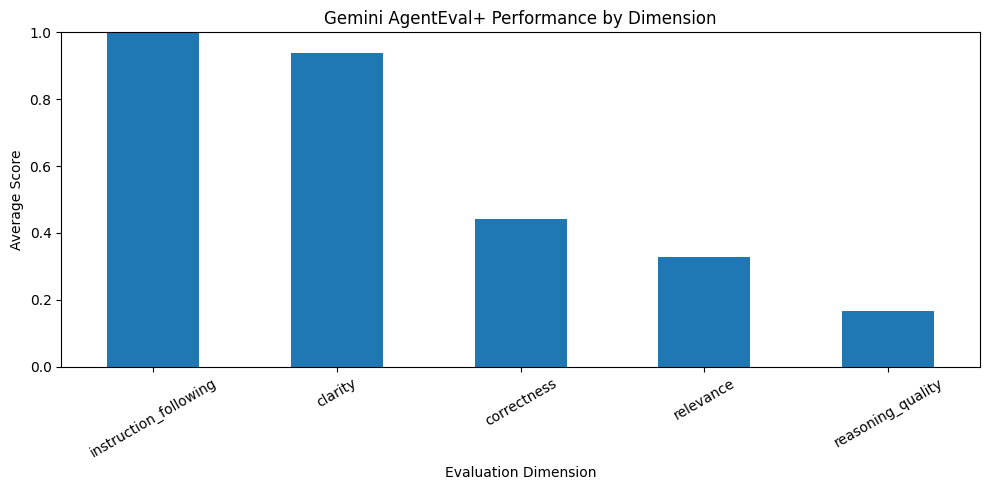

In [49]:


import matplotlib.pyplot as plt

dimension_scores = (
    gemini_eval_df[metric_columns]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
dimension_scores.plot(kind="bar")

plt.title("Gemini AgentEval+ Performance by Dimension")
plt.ylabel("Average Score")
plt.xlabel("Evaluation Dimension")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

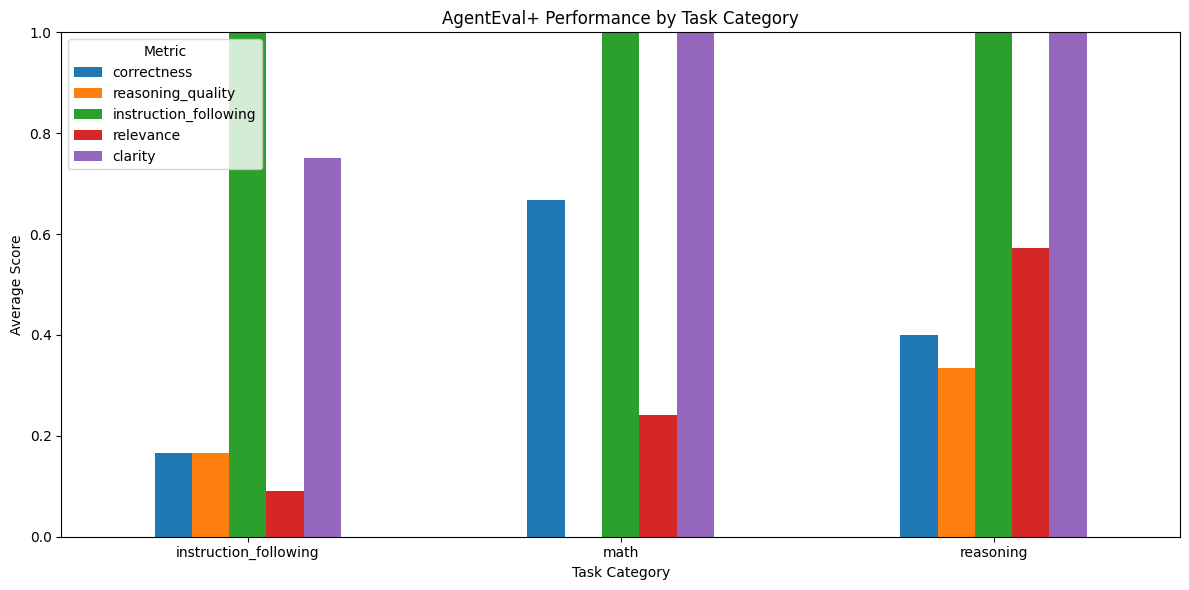

In [50]:


category_dimension = (
    gemini_eval_df
    .groupby("category")[metric_columns]
    .mean()
)

ax = category_dimension.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("AgentEval+ Performance by Task Category")
plt.ylabel("Average Score")
plt.xlabel("Task Category")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

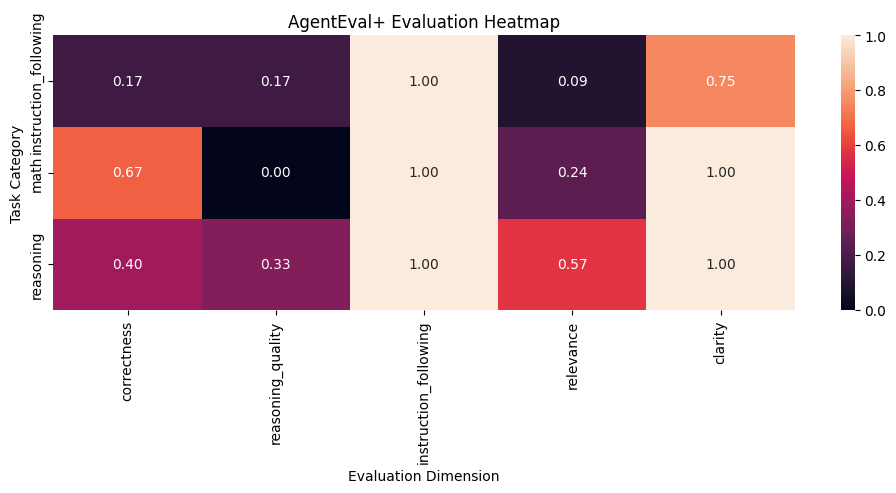

In [51]:

import seaborn as sns

plt.figure(figsize=(10, 5))

sns.heatmap(
    category_dimension,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1
)

plt.title("AgentEval+ Evaluation Heatmap")
plt.xlabel("Evaluation Dimension")
plt.ylabel("Task Category")
plt.tight_layout()
plt.show()

In [52]:

task_scores = gemini_eval_df[
    [
        "task_id",
        "category",
        "overall_score"
    ]
].sort_values(
    "overall_score"
)

display(task_scores)

,task_id,category,overall_score
6,instruction_001,instruction_following,0.384848
2,math_003,math,0.457143
4,reasoning_002,reasoning,0.482353
7,instruction_002,instruction_following,0.484848
0,math_001,math,0.630769
1,math_002,math,0.657143
5,reasoning_003,reasoning,0.685470
3,reasoning_001,reasoning,0.815751


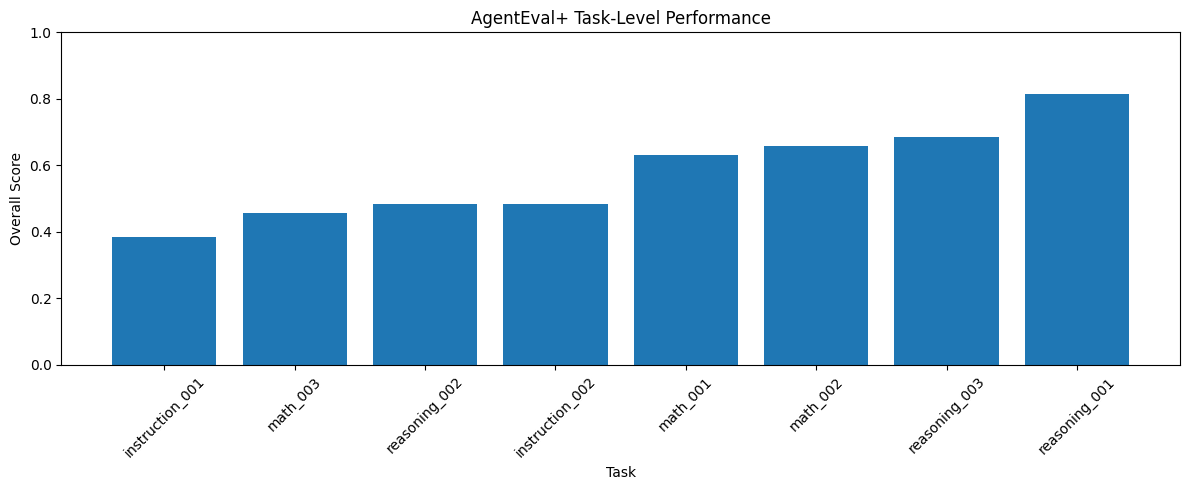

In [53]:
plt.figure(figsize=(12, 5))

plt.bar(
    task_scores["task_id"],
    task_scores["overall_score"]
)

plt.title("AgentEval+ Task-Level Performance")
plt.ylabel("Overall Score")
plt.xlabel("Task")
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

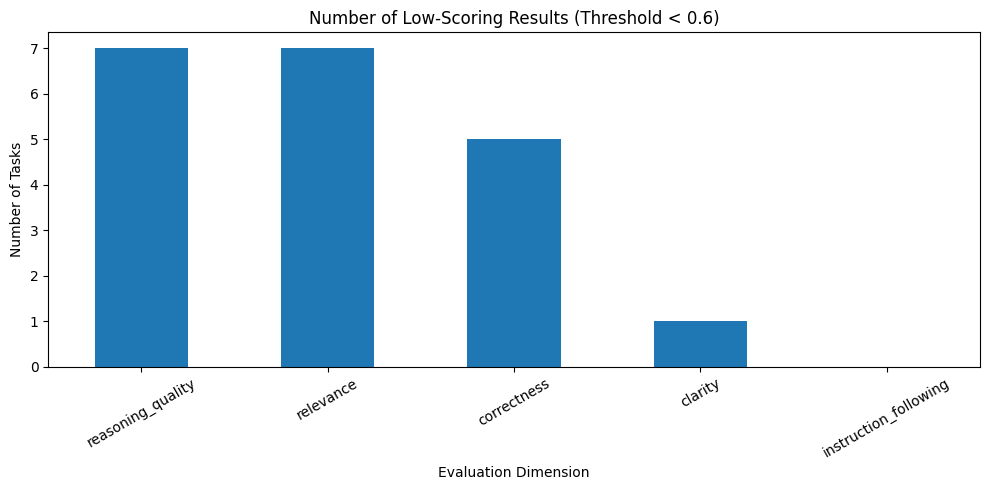

In [54]:

failure_counts = (
    gemini_eval_df[metric_columns] < failure_threshold
).sum()

plt.figure(figsize=(10, 5))

failure_counts.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title(
    f"Number of Low-Scoring Results "
    f"(Threshold < {failure_threshold})"
)

plt.ylabel("Number of Tasks")
plt.xlabel("Evaluation Dimension")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [55]:
plt.savefig(
    "results/overall_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# 19. Statistical Analysis

In [56]:

import numpy as np
from scipy import stats

statistics_results = []

for metric in metric_columns:

    values = gemini_eval_df[metric].dropna()

    n = len(values)
    mean = values.mean()
    std = values.std(ddof=1)

    # 95% confidence interval using t-distribution
    if n > 1:
        standard_error = stats.sem(values)
        confidence_interval = stats.t.interval(
            0.95,
            df=n - 1,
            loc=mean,
            scale=standard_error
        )
    else:
        confidence_interval = (mean, mean)

    statistics_results.append({
        "metric": metric,
        "n": n,
        "mean": mean,
        "std": std,
        "ci_lower": confidence_interval[0],
        "ci_upper": confidence_interval[1]
    })

statistics_df = pd.DataFrame(statistics_results)

display(
    statistics_df.round(3)
)

/usr/local/lib/python3.13/dist-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.13/dist-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,metric,n,mean,std,ci_lower,ci_upper
0,correctness,8,0.441,0.427,0.085,0.798
1,reasoning_quality,8,0.167,0.252,-0.044,0.377
2,instruction_following,8,1.000,0.000,NaN,NaN
3,relevance,8,0.328,0.237,0.130,0.526
4,clarity,8,0.938,0.177,0.790,1.085


In [57]:

category_statistics = []

for category in gemini_eval_df["category"].unique():

    category_data = gemini_eval_df[
        gemini_eval_df["category"] == category
    ]

    for metric in metric_columns:

        values = category_data[metric].dropna()

        n = len(values)
        mean = values.mean()

        if n > 1:
            std = values.std(ddof=1)
            standard_error = stats.sem(values)

            ci = stats.t.interval(
                0.95,
                df=n - 1,
                loc=mean,
                scale=standard_error
            )

            ci_lower, ci_upper = ci

        else:
            std = 0
            ci_lower = mean
            ci_upper = mean

        category_statistics.append({
            "category": category,
            "metric": metric,
            "n": n,
            "mean": mean,
            "std": std,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper
        })

category_statistics_df = pd.DataFrame(
    category_statistics
)

display(
    category_statistics_df.round(3)
)

/usr/local/lib/python3.13/dist-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.13/dist-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,category,metric,n,mean,std,ci_lower,ci_upper
0,math,correctness,3,0.667,0.577,-0.768,2.101
1,math,reasoning_quality,3,0.000,0.000,NaN,NaN
2,math,instruction_following,3,1.000,0.000,NaN,NaN
3,math,relevance,3,0.242,0.076,0.053,0.431
4,math,clarity,3,1.000,0.000,NaN,NaN
5,reasoning,correctness,3,0.399,0.349,-0.467,1.266
6,reasoning,reasoning_quality,3,0.333,0.333,-0.495,1.161
7,reasoning,instruction_following,3,1.000,0.000,NaN,NaN
8,reasoning,relevance,3,0.573,0.181,0.123,1.023
9,reasoning,clarity,3,1.000,0.000,NaN,NaN


In [58]:

total_tasks = len(gemini_df)

successful_tasks = (
    gemini_df["status"] == "success"
).sum()

failed_tasks = (
    gemini_df["status"] == "failed"
).sum()

success_rate = successful_tasks / total_tasks
failure_rate = failed_tasks / total_tasks

print("Benchmark Reliability")
print("=" * 50)
print(f"Total tasks:       {total_tasks}")
print(f"Successful tasks:  {successful_tasks}")
print(f"Failed tasks:      {failed_tasks}")
print(f"Success rate:      {success_rate:.2%}")
print(f"Failure rate:      {failure_rate:.2%}")

Benchmark Reliability
Total tasks:       9
Successful tasks:  8
Failed tasks:      1
Success rate:      88.89%
Failure rate:      11.11%


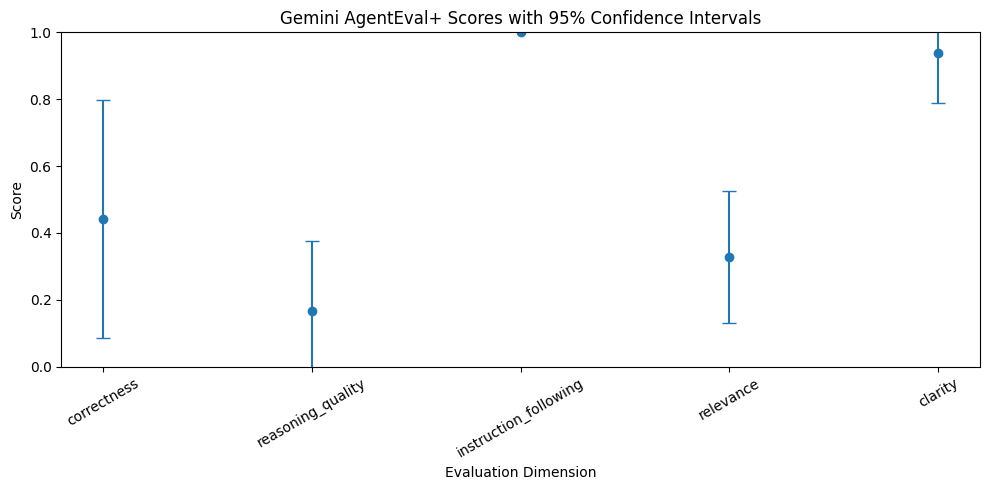

In [59]:

plt.figure(figsize=(10, 5))

x = np.arange(len(statistics_df))

means = statistics_df["mean"].values
lower = statistics_df["ci_lower"].values
upper = statistics_df["ci_upper"].values

errors = np.vstack([
    means - lower,
    upper - means
])

plt.errorbar(
    x,
    means,
    yerr=errors,
    fmt="o",
    capsize=5
)

plt.xticks(
    x,
    statistics_df["metric"],
    rotation=30
)

plt.ylabel("Score")
plt.xlabel("Evaluation Dimension")
plt.title("Gemini AgentEval+ Scores with 95% Confidence Intervals")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# 20. Comparision

In [65]:

gemini_comparison_df = gemini_eval_df.copy()

gemini_comparison_df = gemini_comparison_df.rename(
    columns={
        "overall_score": "overall"
    }
)

# Add failure mode
gemini_comparison_df["failure_mode"] = np.where(
    gemini_comparison_df["overall"] < failure_threshold,
    "low_overall_score",
    "none"
)

# Ensure same column order as existing evaluation_df
comparison_columns = [
    "agent",
    "task_id",
    "category",
    "prompt",
    "response",
    "correctness",
    "reasoning_quality",
    "instruction_following",
    "relevance",
    "clarity",
    "overall",
    "failure_mode"
]

gemini_comparison_df = gemini_comparison_df[
    comparison_columns
]

display(gemini_comparison_df.head())

,agent,task_id,category,prompt,response,correctness,reasoning_quality,instruction_following,relevance,clarity,overall,failure_mode
0,Gemini,math_001,math,A train travels 120 km in 2 hours. What is its...,The average speed is **60 km/h**.\n\n$$\text{S...,1.000000,0.000000,1.0,0.153846,1.0,0.630769,none
1,Gemini,math_002,math,"If a shirt costs $40 and is discounted by 25%,...",The sale price is **$30**.\n\n**Calculation:**...,1.000000,0.000000,1.0,0.285714,1.0,0.657143,none
2,Gemini,math_003,math,A rectangle has length 12 cm and width 5 cm. W...,The area of the rectangle is **60 cm²** (squar...,0.000000,0.000000,1.0,0.285714,1.0,0.457143,low_overall_score
3,Gemini,reasoning_001,reasoning,All roses are flowers. Some flowers fade quick...,"**No**, we cannot conclude that some roses fad...",0.642857,0.666667,1.0,0.769231,1.0,0.815751,none
4,Gemini,reasoning_002,reasoning,A box contains only red and blue balls. If eve...,"**No.** \n\nSince every red ball was removed, ...",0.000000,0.000000,1.0,0.411765,1.0,0.482353,low_overall_score


In [66]:

all_evaluations = pd.concat(
    [
        evaluation_df,
        gemini_comparison_df
    ],
    ignore_index=True
)

print("Total evaluations:", len(all_evaluations))
print("\nEvaluations by agent:")

display(
    all_evaluations["agent"].value_counts()
)

Total evaluations: 26

Evaluations by agent:


,count
agent,
Agent_A,9
Agent_B,9
Gemini,8


In [67]:

agent_comparison = (
    all_evaluations
    .groupby("agent")
    .agg(
        tasks=("task_id", "count"),
        overall_score=("overall", "mean"),
        correctness=("correctness", "mean"),
        reasoning_quality=("reasoning_quality", "mean"),
        instruction_following=("instruction_following", "mean"),
        relevance=("relevance", "mean"),
        clarity=("clarity", "mean")
    )
    .round(3)
)

display(agent_comparison)

,tasks,overall_score,correctness,reasoning_quality,instruction_following,relevance,clarity
agent,,,,,,,
Agent_A,9,3.378,3.889,2.333,2.667,4.000,4.000
Agent_B,9,2.378,0.889,1.333,1.667,4.000,4.000
Gemini,8,0.575,0.441,0.167,1.000,0.328,0.938


In [68]:

category_comparison = (
    all_evaluations
    .groupby(["agent", "category"])[metric_columns + ["overall"]]
    .mean()
    .round(3)
)

display(category_comparison)

correctness  reasoning_quality  \
agent   category                                                
Agent_A instruction_following        3.667              2.000   
        math                         4.000              3.000   
        reasoning                    4.000              2.000   
Agent_B instruction_following        2.667              2.000   
        math                         0.000              1.000   
        reasoning                    0.000              1.000   
Gemini  instruction_following        0.167              0.167   
        math                         0.667              0.000   
        reasoning                    0.399              0.333   

                               instruction_following  relevance  clarity  \
agent   category                                                           
Agent_A instruction_following                    4.0      4.000     4.00   
        math                                     2.0      4.000     4.00   
        reasoning                                2.0      4.000     4.00   
Agent_B instruction_following                    1.0      4.000     4.00   
        math                                     2.0      4.000     4.00   
        reasoning                                2.0      4.000     4.00   
Gemini  instruction_following                    1.0      0.091     0.75   
        math                                     1.0      0.242     1.00   
        reasoning                                1.0      0.573     1.00   

                               overall  
agent   category                        
Agent_A instruction_following    3.533  
        math                     3.400  
        reasoning                3.200  
Agent_B instruction_following    2.733  
        math                     2.200  
        reasoning                2.200  
Gemini  instruction_following    0.435  
        math                     0.582  
        reasoning                0.661

In [69]:

agent_metric_matrix = (
    all_evaluations
    .groupby("agent")[metric_columns + ["overall"]]
    .mean()
)

display(
    agent_metric_matrix.round(3)
)

,correctness,reasoning_quality,instruction_following,relevance,clarity,overall
agent,,,,,,
Agent_A,3.889,2.333,2.667,4.000,4.000,3.378
Agent_B,0.889,1.333,1.667,4.000,4.000,2.378
Gemini,0.441,0.167,1.000,0.328,0.938,0.575


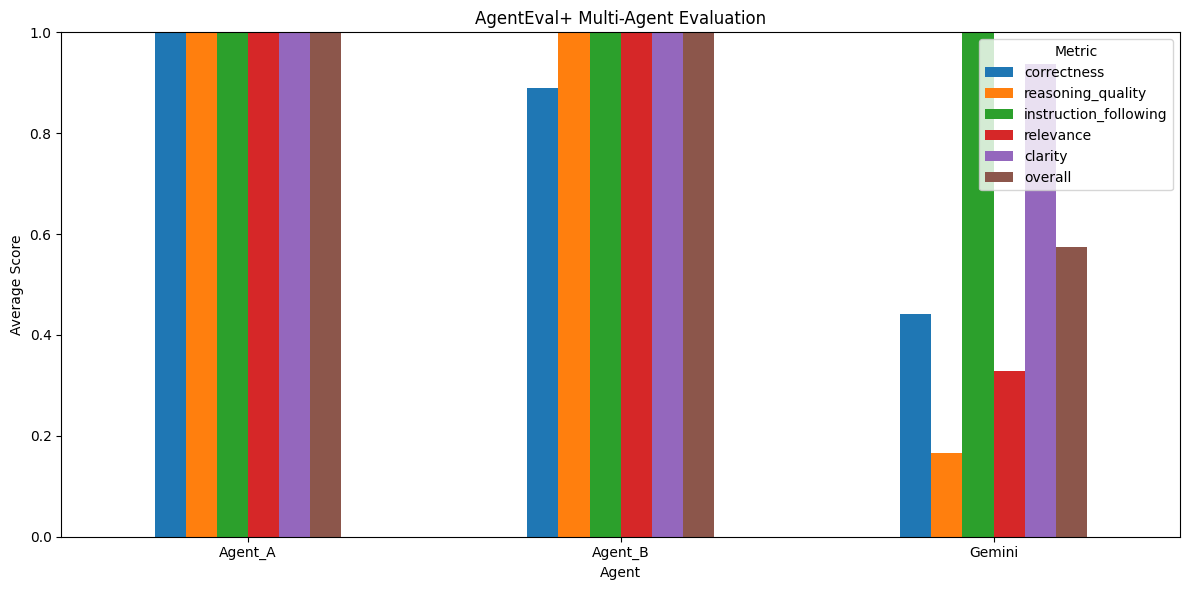

In [70]:

agent_metric_matrix.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("AgentEval+ Multi-Agent Evaluation")
plt.ylabel("Average Score")
plt.xlabel("Agent")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

In [71]:

all_evaluations.to_csv(
    "results/all_agent_evaluations.csv",
    index=False
)

agent_comparison.to_csv(
    "results/agent_comparison.csv"
)

category_comparison.to_csv(
    "results/category_comparison.csv"
)

print("Multi-agent results saved successfully.")

Multi-agent results saved successfully.


# 21. Common Tasks

Agents: ['Agent_A', 'Agent_B', 'Gemini']
Common tasks: ['instruction_001', 'instruction_002', 'math_001', 'math_002', 'math_003', 'reasoning_001', 'reasoning_002', 'reasoning_003']
Number of common tasks: 8

Matched evaluation shape: (24, 13)
agent
Agent_A    8
Agent_B    8
Gemini     8

=== MATCHED-TASK AGENT SUMMARY ===


,agent,tasks,overall,correctness,reasoning_quality,instruction_following,relevance,clarity
0,Agent_A,8,3.350,3.875,2.375,2.50,4.000,4.000
1,Agent_B,8,2.375,0.875,1.250,1.75,4.000,4.000
2,Gemini,8,0.575,0.441,0.167,1.00,0.328,0.938



=== MATCHED-TASK CATEGORY SUMMARY ===


,agent,category,tasks,overall,correctness,reasoning_quality,instruction_following,relevance,clarity
0,Agent_A,instruction_following,2,3.500,3.500,2.000,4.0,4.000,4.00
1,Agent_A,math,3,3.400,4.000,3.000,2.0,4.000,4.00
2,Agent_A,reasoning,3,3.200,4.000,2.000,2.0,4.000,4.00
3,Agent_B,instruction_following,2,2.900,3.500,2.000,1.0,4.000,4.00
4,Agent_B,math,3,2.200,0.000,1.000,2.0,4.000,4.00
5,Agent_B,reasoning,3,2.200,0.000,1.000,2.0,4.000,4.00
6,Gemini,instruction_following,2,0.435,0.167,0.167,1.0,0.091,0.75
7,Gemini,math,3,0.582,0.667,0.000,1.0,0.242,1.00
8,Gemini,reasoning,3,0.661,0.399,0.333,1.0,0.573,1.00



=== PER-TASK OVERALL SCORE COMPARISON ===


agent,task_id,category,Agent_A,Agent_B,Gemini
0,instruction_001,instruction_following,3.6,3.0,0.385
1,instruction_002,instruction_following,3.4,2.8,0.485
2,math_001,math,3.6,2.2,0.631
3,math_002,math,3.0,2.2,0.657
4,math_003,math,3.6,2.2,0.457
5,reasoning_001,reasoning,3.6,2.2,0.816
6,reasoning_002,reasoning,3.0,2.2,0.482
7,reasoning_003,reasoning,3.0,2.2,0.685


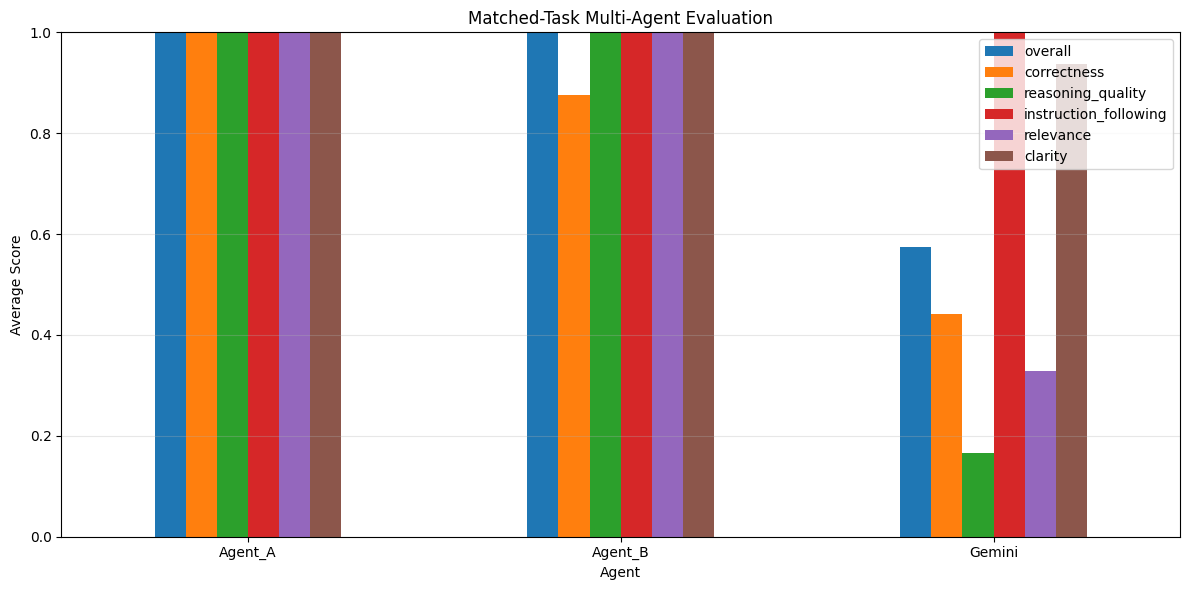

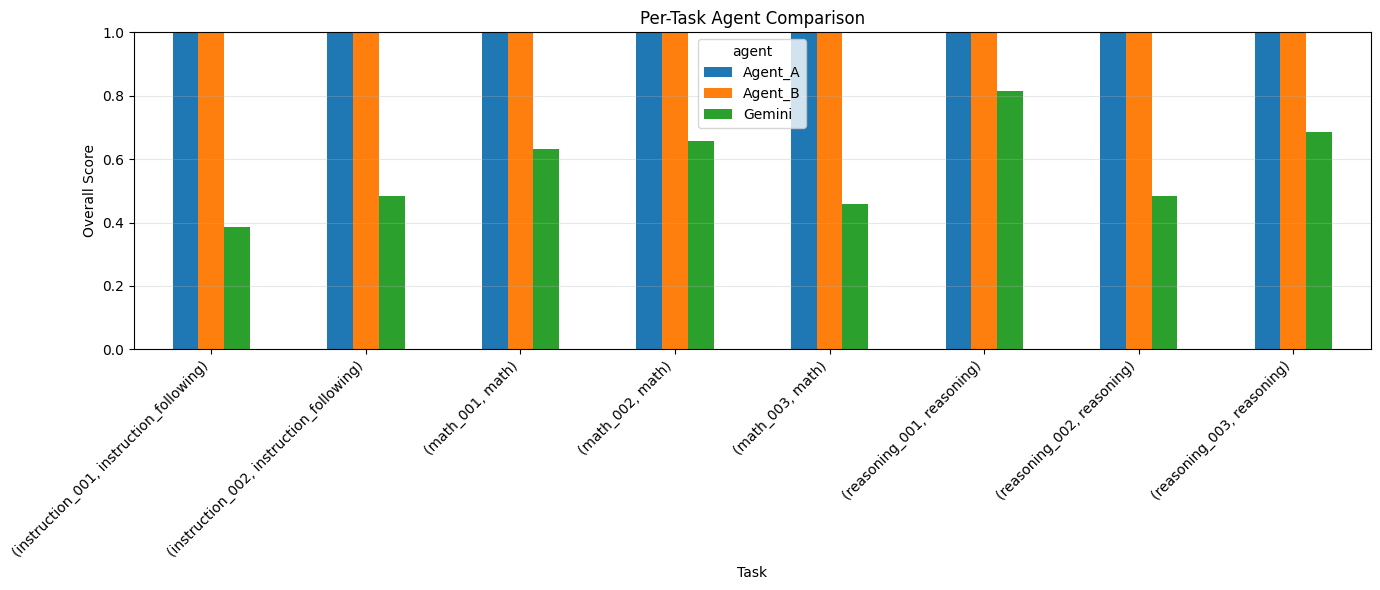


STEP 21 COMPLETED
Common tasks evaluated by all agents : 8
Matched evaluation rows              : 24

Saved files:
✓ results/matched_agent_evaluations.csv
✓ results/matched_agent_summary.csv
✓ results/matched_category_summary.csv
✓ results/per_task_agent_comparison.csv

Note:
This comparison uses only tasks evaluated by ALL agents,
so agents are compared on the same task set.


In [72]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



agent_task_sets = (
    all_evaluations
    .groupby("agent")["task_id"]
    .apply(set)
)

common_tasks = set.intersection(*agent_task_sets.tolist())

print("Agents:", sorted(agent_task_sets.index))
print("Common tasks:", sorted(common_tasks))
print("Number of common tasks:", len(common_tasks))



matched_evaluations = all_evaluations[
    all_evaluations["task_id"].isin(common_tasks)
].copy()

print("\nMatched evaluation shape:", matched_evaluations.shape)
print(
    matched_evaluations.groupby("agent")["task_id"]
    .count()
    .to_string()
)




metrics = [
    "overall",
    "correctness",
    "reasoning_quality",
    "instruction_following",
    "relevance",
    "clarity"
]

matched_summary = (
    matched_evaluations
    .groupby("agent")
    .agg(
        tasks=("task_id", "nunique"),
        overall=("overall", "mean"),
        correctness=("correctness", "mean"),
        reasoning_quality=("reasoning_quality", "mean"),
        instruction_following=("instruction_following", "mean"),
        relevance=("relevance", "mean"),
        clarity=("clarity", "mean")
    )
    .reset_index()
)

print("\n=== MATCHED-TASK AGENT SUMMARY ===")
display(matched_summary.round(3))


matched_category_summary = (
    matched_evaluations
    .groupby(["agent", "category"])
    .agg(
        tasks=("task_id", "nunique"),
        overall=("overall", "mean"),
        correctness=("correctness", "mean"),
        reasoning_quality=("reasoning_quality", "mean"),
        instruction_following=("instruction_following", "mean"),
        relevance=("relevance", "mean"),
        clarity=("clarity", "mean")
    )
    .reset_index()
)

print("\n=== MATCHED-TASK CATEGORY SUMMARY ===")
display(matched_category_summary.round(3))



task_comparison = (
    matched_evaluations
    .pivot_table(
        index=["task_id", "category"],
        columns="agent",
        values="overall"
    )
    .reset_index()
)

print("\n=== PER-TASK OVERALL SCORE COMPARISON ===")
display(task_comparison.round(3))


plot_data = (
    matched_summary
    .set_index("agent")[metrics]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Matched-Task Multi-Agent Evaluation")
ax.set_xlabel("Agent")
ax.set_ylabel("Average Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



task_plot = task_comparison.set_index(
    ["task_id", "category"]
)

ax = task_plot.plot(
    kind="bar",
    figsize=(14, 6)
)

ax.set_title("Per-Task Agent Comparison")
ax.set_xlabel("Task")
ax.set_ylabel("Overall Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



os.makedirs("results", exist_ok=True)

matched_evaluations.to_csv(
    "results/matched_agent_evaluations.csv",
    index=False
)

matched_summary.to_csv(
    "results/matched_agent_summary.csv",
    index=False
)

matched_category_summary.to_csv(
    "results/matched_category_summary.csv",
    index=False
)

task_comparison.to_csv(
    "results/per_task_agent_comparison.csv",
    index=False
)


print("\n" + "=" * 60)
print("STEP 21 COMPLETED")
print("=" * 60)

print(f"Common tasks evaluated by all agents : {len(common_tasks)}")
print(f"Matched evaluation rows              : {len(matched_evaluations)}")

print("\nSaved files:")
print("✓ results/matched_agent_evaluations.csv")
print("✓ results/matched_agent_summary.csv")
print("✓ results/matched_category_summary.csv")
print("✓ results/per_task_agent_comparison.csv")

print("\nNote:")
print("This comparison uses only tasks evaluated by ALL agents,")
print("so agents are compared on the same task set.")

# 22. Analysis

=== FAILURE SUMMARY BY AGENT ===


,agent,total_tasks,failures,failure_rate
0,Agent_A,9,0,0.0
1,Agent_B,9,0,0.0
2,Gemini,8,4,0.5



=== FAILURE SUMMARY BY CATEGORY ===


,agent,category,total_tasks,failures,average_score,failure_rate
0,Agent_A,instruction_following,3,0,3.533,0.000
1,Agent_A,math,3,0,3.400,0.000
2,Agent_A,reasoning,3,0,3.200,0.000
3,Agent_B,instruction_following,3,0,2.733,0.000
4,Agent_B,math,3,0,2.200,0.000
5,Agent_B,reasoning,3,0,2.200,0.000
6,Gemini,instruction_following,2,2,0.435,1.000
7,Gemini,math,3,1,0.582,0.333
8,Gemini,reasoning,3,1,0.661,0.333



=== FAILURE ANALYSIS BY DIMENSION ===


...

,agent,task_id,category,overall,correctness,reasoning_quality,instruction_following,relevance,clarity,failure_mode
24,Gemini,instruction_001,instruction_following,0.385,0.333,0.000,1.0,0.091,0.5,low_overall_score
20,Gemini,math_003,math,0.457,0.000,0.000,1.0,0.286,1.0,low_overall_score
22,Gemini,reasoning_002,reasoning,0.482,0.000,0.000,1.0,0.412,1.0,low_overall_score
25,Gemini,instruction_002,instruction_following,0.485,0.000,0.333,1.0,0.091,1.0,low_overall_score



=== FAILURE MATRIX BY TASK ===


agent,Agent_A,Agent_B,Gemini
task_id,,,
instruction_001,False,False,True
instruction_002,False,False,True
instruction_003,False,False,False
math_001,False,False,False
math_002,False,False,False
math_003,False,False,True
reasoning_001,False,False,False
reasoning_002,False,False,True
reasoning_003,False,False,False



=== LOW-SCORE TASKS BY DIMENSION ===


agent,Agent_A,Agent_B,Gemini
dimension,,,
clarity,0,0,1
correctness,0,6,5
instruction_following,0,0,0
reasoning_quality,0,0,7
relevance,0,0,7


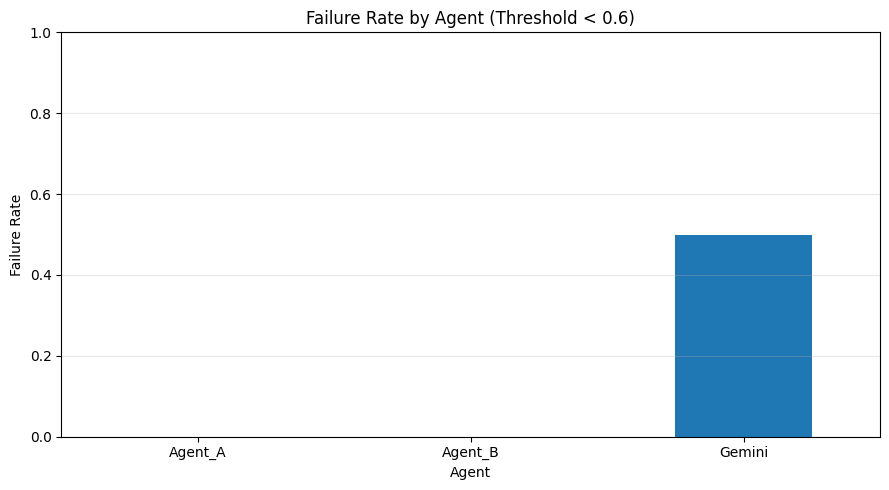

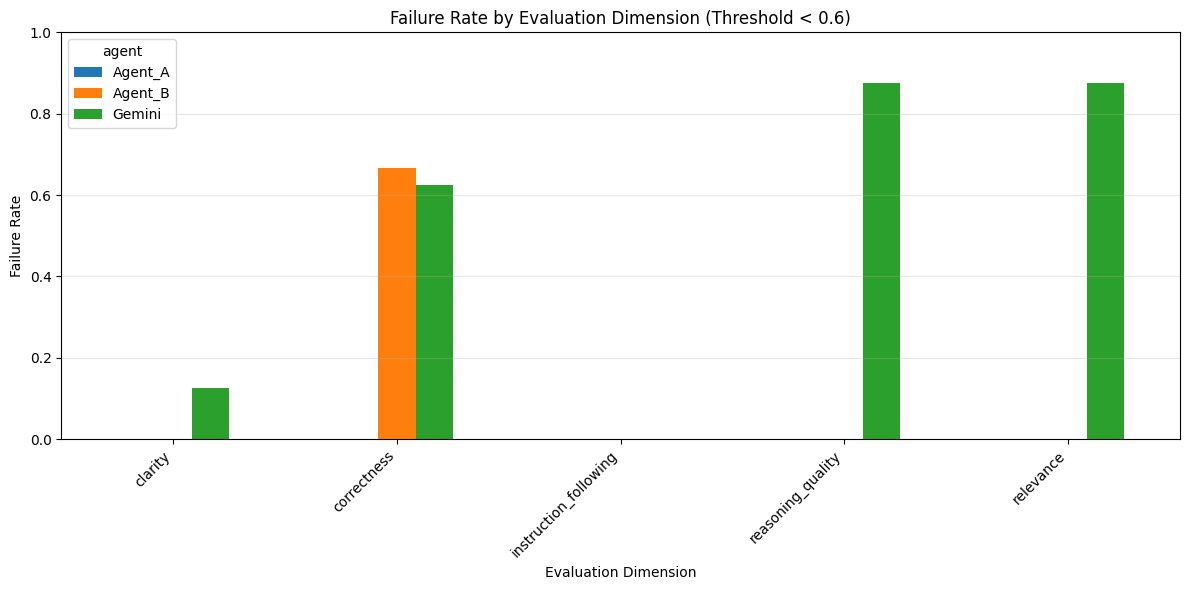

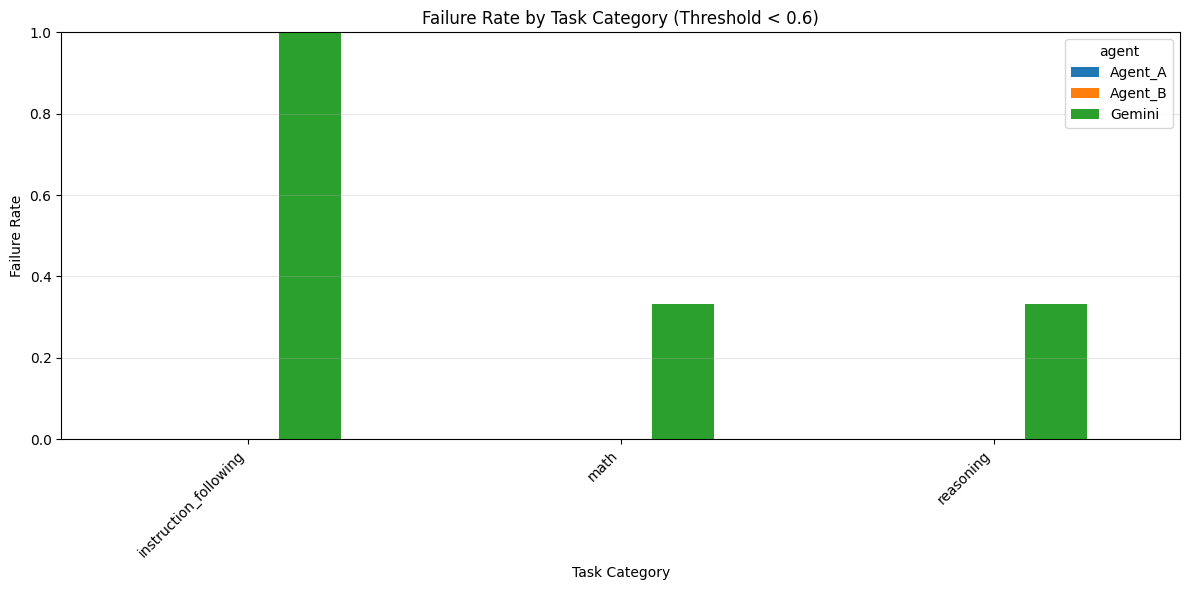


STEP 22 COMPLETED
Failure threshold: 0.6
Total evaluations: 26
Total failure cases: 4

Failure counts by agent:
  agent  total_tasks  failures  failure_rate
Agent_A            9         0           0.0
Agent_B            9         0           0.0
 Gemini            8         4           0.5

Saved files:
✓ results/failure_by_agent.csv
✓ results/failure_by_category.csv
✓ results/failure_by_dimension.csv
✓ results/failure_cases.csv
✓ results/failure_task_matrix.csv
✓ results/failure_dimension_matrix.csv


In [73]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define failure threshold
# ------------------------------------------------------------

failure_threshold = 0.60

failure_analysis = all_evaluations.copy()

# Identify whether each evaluation is a potential failure
failure_analysis["is_failure"] = (
    failure_analysis["overall"] < failure_threshold
)

# ------------------------------------------------------------
# 2. Failure count by agent
# ------------------------------------------------------------

failure_by_agent = (
    failure_analysis
    .groupby("agent")
    .agg(
        total_tasks=("task_id", "count"),
        failures=("is_failure", "sum")
    )
    .reset_index()
)

failure_by_agent["failure_rate"] = (
    failure_by_agent["failures"] /
    failure_by_agent["total_tasks"]
)

print("=== FAILURE SUMMARY BY AGENT ===")
display(failure_by_agent.round(3))


# ------------------------------------------------------------
# 3. Failure count by agent and category
# ------------------------------------------------------------

failure_by_category = (
    failure_analysis
    .groupby(["agent", "category"])
    .agg(
        total_tasks=("task_id", "count"),
        failures=("is_failure", "sum"),
        average_score=("overall", "mean")
    )
    .reset_index()
)

failure_by_category["failure_rate"] = (
    failure_by_category["failures"] /
    failure_by_category["total_tasks"]
)

print("\n=== FAILURE SUMMARY BY CATEGORY ===")
display(failure_by_category.round(3))


# ------------------------------------------------------------
# 4. Failure analysis by evaluation dimension
# ------------------------------------------------------------

dimensions = [
    "correctness",
    "reasoning_quality",
    "instruction_following",
    "relevance",
    "clarity"
]

dimension_failure_rows = []

for agent in failure_analysis["agent"].unique():

    agent_data = failure_analysis[
        failure_analysis["agent"] == agent
    ]

    for dimension in dimensions:

        low_score_count = (
            agent_data[dimension] < failure_threshold
        ).sum()

        dimension_failure_rows.append({
            "agent": agent,
            "dimension": dimension,
            "low_score_tasks": int(low_score_count),
            "total_tasks": len(agent_data),
            "failure_rate": low_score_count / len(agent_data)
        })

dimension_failures = pd.DataFrame(
    dimension_failure_rows
)

print("\n=== FAILURE ANALYSIS BY DIMENSION ===")
display(dimension_failures.round(3))


# ------------------------------------------------------------
# 5. Identify individual failure cases
# ------------------------------------------------------------

failure_cases = failure_analysis[
    failure_analysis["is_failure"]
].copy()

failure_cases = failure_cases.sort_values(
    ["agent", "overall"]
)

failure_columns = [
    "agent",
    "task_id",
    "category",
    "overall",
    "correctness",
    "reasoning_quality",
    "instruction_following",
    "relevance",
    "clarity",
    "failure_mode"
]


failure_columns = [
    col for col in failure_columns
    if col in failure_cases.columns
]

print("\n=== INDIVIDUAL FAILURE CASES ===")
display(
    failure_cases[failure_columns].round(3)
)


# ------------------------------------------------------------
# 6. Failure cases by task
# ------------------------------------------------------------

failure_task_matrix = (
    failure_analysis
    .pivot_table(
        index="task_id",
        columns="agent",
        values="is_failure",
        aggfunc="max",
        fill_value=False
    )
)

print("\n=== FAILURE MATRIX BY TASK ===")
display(failure_task_matrix)


# ------------------------------------------------------------
# 7. Failure cases by dimension
# ------------------------------------------------------------

dimension_matrix = (
    dimension_failures
    .pivot(
        index="dimension",
        columns="agent",
        values="low_score_tasks"
    )
    .fillna(0)
)

print("\n=== LOW-SCORE TASKS BY DIMENSION ===")
display(dimension_matrix.astype(int))


# ------------------------------------------------------------
# 8. Failure visualization — failure rate by agent
# ------------------------------------------------------------

ax = failure_by_agent.set_index("agent")[
    "failure_rate"
].plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    f"Failure Rate by Agent (Threshold < {failure_threshold})"
)

ax.set_xlabel("Agent")
ax.set_ylabel("Failure Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Failure visualization — dimensions
# ------------------------------------------------------------

dimension_plot = dimension_failures.pivot(
    index="dimension",
    columns="agent",
    values="failure_rate"
)

ax = dimension_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    f"Failure Rate by Evaluation Dimension "
    f"(Threshold < {failure_threshold})"
)

ax.set_xlabel("Evaluation Dimension")
ax.set_ylabel("Failure Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Failure visualization — categories
# ------------------------------------------------------------

category_plot = failure_by_category.pivot(
    index="category",
    columns="agent",
    values="failure_rate"
)

ax = category_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    f"Failure Rate by Task Category "
    f"(Threshold < {failure_threshold})"
)

ax.set_xlabel("Task Category")
ax.set_ylabel("Failure Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Save failure analysis results
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

failure_by_agent.to_csv(
    "results/failure_by_agent.csv",
    index=False
)

failure_by_category.to_csv(
    "results/failure_by_category.csv",
    index=False
)

dimension_failures.to_csv(
    "results/failure_by_dimension.csv",
    index=False
)

failure_cases.to_csv(
    "results/failure_cases.csv",
    index=False
)

failure_task_matrix.to_csv(
    "results/failure_task_matrix.csv"
)

dimension_matrix.to_csv(
    "results/failure_dimension_matrix.csv"
)


# ------------------------------------------------------------
# 12. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 22 COMPLETED")
print("=" * 60)

print(f"Failure threshold: {failure_threshold}")
print(f"Total evaluations: {len(failure_analysis)}")
print(f"Total failure cases: {failure_analysis['is_failure'].sum()}")

print("\nFailure counts by agent:")
print(
    failure_by_agent[
        ["agent", "total_tasks", "failures", "failure_rate"]
    ].round(3).to_string(index=False)
)

print("\nSaved files:")
print("✓ results/failure_by_agent.csv")
print("✓ results/failure_by_category.csv")
print("✓ results/failure_by_dimension.csv")
print("✓ results/failure_cases.csv")
print("✓ results/failure_task_matrix.csv")
print("✓ results/failure_dimension_matrix.csv")

# 23. Report

In [74]:


import os
import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create results directory
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)


# ------------------------------------------------------------
# 2. Final agent-level summary
# ------------------------------------------------------------

final_agent_summary = (
    all_evaluations
    .groupby("agent")
    .agg(
        tasks=("task_id", "nunique"),
        evaluations=("task_id", "count"),
        overall=("overall", "mean"),
        correctness=("correctness", "mean"),
        reasoning_quality=("reasoning_quality", "mean"),
        instruction_following=("instruction_following", "mean"),
        relevance=("relevance", "mean"),
        clarity=("clarity", "mean")
    )
    .reset_index()
)

print("=== FINAL AGENT SUMMARY ===")
display(final_agent_summary.round(3))


# ------------------------------------------------------------
# 3. Final category summary
# ------------------------------------------------------------

final_category_summary = (
    all_evaluations
    .groupby(["agent", "category"])
    .agg(
        tasks=("task_id", "nunique"),
        overall=("overall", "mean"),
        correctness=("correctness", "mean"),
        reasoning_quality=("reasoning_quality", "mean"),
        instruction_following=("instruction_following", "mean"),
        relevance=("relevance", "mean"),
        clarity=("clarity", "mean")
    )
    .reset_index()
)

print("\n=== FINAL CATEGORY SUMMARY ===")
display(final_category_summary.round(3))


# ------------------------------------------------------------
# 4. Overall project statistics
# ------------------------------------------------------------

total_evaluations = len(all_evaluations)
total_agents = all_evaluations["agent"].nunique()
total_tasks = all_evaluations["task_id"].nunique()

failure_count = int(
    (all_evaluations["overall"] < failure_threshold).sum()
)

failure_rate = (
    failure_count / total_evaluations
    if total_evaluations > 0
    else 0
)

project_statistics = {
    "total_agents": int(total_agents),
    "total_unique_tasks": int(total_tasks),
    "total_evaluations": int(total_evaluations),
    "failure_threshold": float(failure_threshold),
    "failure_cases": failure_count,
    "overall_failure_rate": float(failure_rate),
    "common_tasks_across_all_agents": int(len(common_tasks)),
    "matched_evaluations": int(len(matched_evaluations))
}

print("\n=== PROJECT STATISTICS ===")

for key, value in project_statistics.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 5. Dimension-level project summary
# ------------------------------------------------------------

dimension_summary = (
    all_evaluations[
        [
            "correctness",
            "reasoning_quality",
            "instruction_following",
            "relevance",
            "clarity"
        ]
    ]
    .mean()
    .reset_index()
)

dimension_summary.columns = [
    "dimension",
    "average_score"
]

print("\n=== OVERALL DIMENSION PERFORMANCE ===")
display(dimension_summary.round(3))


# ------------------------------------------------------------
# 6. Create final machine-readable JSON report
# ------------------------------------------------------------

final_report = {
    "project": "AgentEval+",
    "description": (
        "Multi-Dimensional AI Agent Evaluation "
        "and Failure Analysis Framework"
    ),
    "statistics": project_statistics,
    "agents": final_agent_summary.to_dict(orient="records"),
    "categories": final_category_summary.to_dict(orient="records"),
    "dimensions": dimension_summary.to_dict(orient="records")
}

with open(
    "results/final_evaluation_report.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_report,
        f,
        indent=2,
        default=lambda x: float(x)
        if isinstance(x, (np.float64, np.float32))
        else x
    )


# ------------------------------------------------------------
# 7. Export final complete dataset
# ------------------------------------------------------------

all_evaluations.to_csv(
    "results/final_all_evaluations.csv",
    index=False
)

final_agent_summary.to_csv(
    "results/final_agent_summary.csv",
    index=False
)

final_category_summary.to_csv(
    "results/final_category_summary.csv",
    index=False
)

dimension_summary.to_csv(
    "results/final_dimension_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 8. Create a human-readable summary
# ------------------------------------------------------------

summary_lines = [
    "AgentEval+ — Final Evaluation Report",
    "=" * 50,
    "",
    f"Agents evaluated: {total_agents}",
    f"Unique tasks: {total_tasks}",
    f"Total evaluations: {total_evaluations}",
    f"Common tasks across all agents: {len(common_tasks)}",
    f"Matched evaluations: {len(matched_evaluations)}",
    f"Failure threshold: {failure_threshold}",
    f"Failure cases: {failure_count}",
    f"Overall failure rate: {failure_rate:.2%}",
    "",
    "Agent Summary",
    "-" * 50
]

for _, row in final_agent_summary.iterrows():
    summary_lines.append(
        f"{row['agent']}: "
        f"overall={row['overall']:.3f}, "
        f"correctness={row['correctness']:.3f}, "
        f"reasoning={row['reasoning_quality']:.3f}, "
        f"instruction_following={row['instruction_following']:.3f}, "
        f"relevance={row['relevance']:.3f}, "
        f"clarity={row['clarity']:.3f}"
    )

summary_lines.extend([
    "",
    "Dimension Summary",
    "-" * 50
])

for _, row in dimension_summary.iterrows():
    summary_lines.append(
        f"{row['dimension']}: "
        f"{row['average_score']:.3f}"
    )

with open(
    "results/FINAL_REPORT.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(summary_lines))


# ------------------------------------------------------------
# 9. Display final report
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("AGENTEVAL+ — FINAL REPORT")
print("=" * 65)

print(f"\nAgents evaluated       : {total_agents}")
print(f"Unique tasks           : {total_tasks}")
print(f"Total evaluations      : {total_evaluations}")
print(f"Common tasks           : {len(common_tasks)}")
print(f"Matched evaluations    : {len(matched_evaluations)}")
print(f"Failure cases          : {failure_count}")
print(f"Failure rate           : {failure_rate:.2%}")

print("\nFinal agent summary:")
display(final_agent_summary.round(3))

print("\nOverall dimension summary:")
display(dimension_summary.round(3))

print("\n" + "=" * 65)
print("STEP 23 COMPLETED")
print("=" * 65)

print("\nFinal files created:")
print("✓ results/final_all_evaluations.csv")
print("✓ results/final_agent_summary.csv")
print("✓ results/final_category_summary.csv")
print("✓ results/final_dimension_summary.csv")
print("✓ results/final_evaluation_report.json")
print("✓ results/FINAL_REPORT.txt")

=== FINAL AGENT SUMMARY ===


,agent,tasks,evaluations,overall,correctness,reasoning_quality,instruction_following,relevance,clarity
0,Agent_A,9,9,3.378,3.889,2.333,2.667,4.000,4.000
1,Agent_B,9,9,2.378,0.889,1.333,1.667,4.000,4.000
2,Gemini,8,8,0.575,0.441,0.167,1.000,0.328,0.938



=== FINAL CATEGORY SUMMARY ===


,agent,category,tasks,overall,correctness,reasoning_quality,instruction_following,relevance,clarity
0,Agent_A,instruction_following,3,3.533,3.667,2.000,4.0,4.000,4.00
1,Agent_A,math,3,3.400,4.000,3.000,2.0,4.000,4.00
2,Agent_A,reasoning,3,3.200,4.000,2.000,2.0,4.000,4.00
3,Agent_B,instruction_following,3,2.733,2.667,2.000,1.0,4.000,4.00
4,Agent_B,math,3,2.200,0.000,1.000,2.0,4.000,4.00
5,Agent_B,reasoning,3,2.200,0.000,1.000,2.0,4.000,4.00
6,Gemini,instruction_following,2,0.435,0.167,0.167,1.0,0.091,0.75
7,Gemini,math,3,0.582,0.667,0.000,1.0,0.242,1.00
8,Gemini,reasoning,3,0.661,0.399,0.333,1.0,0.573,1.00



=== PROJECT STATISTICS ===
total_agents: 3
total_unique_tasks: 9
total_evaluations: 26
failure_threshold: 0.6
failure_cases: 4
overall_failure_rate: 0.15384615384615385
common_tasks_across_all_agents: 8
matched_evaluations: 24

=== OVERALL DIMENSION PERFORMANCE ===


...


AGENTEVAL+ — FINAL REPORT

Agents evaluated       : 3
Unique tasks           : 9
Total evaluations      : 26
Common tasks           : 8
Matched evaluations    : 24
Failure cases          : 4
Failure rate           : 15.38%

Final agent summary:


,agent,tasks,evaluations,overall,correctness,reasoning_quality,instruction_following,relevance,clarity
0,Agent_A,9,9,3.378,3.889,2.333,2.667,4.000,4.000
1,Agent_B,9,9,2.378,0.889,1.333,1.667,4.000,4.000
2,Gemini,8,8,0.575,0.441,0.167,1.000,0.328,0.938



Overall dimension summary:


,dimension,average_score
0,correctness,1.790
1,reasoning_quality,1.321
2,instruction_following,1.808
3,relevance,2.870
4,clarity,3.058



STEP 23 COMPLETED

Final files created:
✓ results/final_all_evaluations.csv
✓ results/final_agent_summary.csv
✓ results/final_category_summary.csv
✓ results/final_dimension_summary.csv
✓ results/final_evaluation_report.json
✓ results/FINAL_REPORT.txt
